In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('heartdisease.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [4]:
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [5]:
X = df.drop(columns=['id','Heart Disease'])
y = df['Heart Disease']

### Encoding y labels to 0 & 1 (presence=1)

In [6]:
y = y.map({'Presence':1,'Absence':0})
y.head()

0    1
1    0
2    0
3    0
4    1
Name: Heart Disease, dtype: int64

## Split

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
625149,54,1,4,110,274,0,0,125,1,0.4,1,0,7
276435,59,0,3,145,197,0,2,179,0,0.0,3,0,3
43949,64,0,4,160,204,0,0,125,0,0.0,2,0,7
280523,51,0,3,125,248,0,0,188,0,0.0,1,0,3
619977,64,0,4,130,204,0,2,138,0,0.0,1,0,3


In [9]:
from sklearn.preprocessing import StandardScaler

### Scaling features (StandardScaler)

In [10]:
num_cols = X_train.select_dtypes(include='number').columns
num_cols

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium'],
      dtype='object')

In [11]:
sc = StandardScaler()
sc.fit(X_train[num_cols])

X_train[num_cols] = sc.transform(X_train[num_cols])
X_test[num_cols] = sc.transform(X_test[num_cols])
X_train.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
625149,-0.016521,0.631521,0.806509,-1.367621,0.862166,-0.294928,-0.982791,-1.456751,1.629607,-0.332786,-0.836433,-0.564872,1.221070
276435,0.588907,-1.583479,-0.368138,0.969951,-1.425245,-0.294928,1.019633,1.368821,-0.613645,-0.754717,2.831988,-0.564872,-0.830314
43949,1.194335,-1.583479,0.806509,1.971768,-1.217299,-0.294928,-0.982791,-1.456751,-0.613645,-0.754717,0.997778,-0.564872,1.221070
280523,-0.379778,-1.583479,-0.368138,-0.365805,0.089793,-0.294928,-0.982791,1.839749,-0.613645,-0.754717,-0.836433,-0.564872,-0.830314
619977,1.194335,-1.583479,0.806509,-0.031866,-1.217299,-0.294928,1.019633,-0.776521,-0.613645,-0.754717,-0.836433,-0.564872,-0.830314


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [13]:
from sklearn.model_selection import GridSearchCV , KFold, cross_val_score

### KFold Cross validation to select the best model 

In [14]:
kf = KFold(n_splits=5,random_state=42,shuffle=True)

In [15]:
def cross_val(model, X, y, cv):
    scores = cross_val_score(estimator = model,
                             X=X,
                             y=y,
                             scoring='accuracy',
                             cv=cv,
                             n_jobs=-1,
                            )
    print(f'Scores of Model {model} are : {scores}\n')
    print(f'Average Score : {scores.mean()}\n')
    print(f'Standard Deviation of scores: {scores.std()}\n')

In [16]:
cross_val(model=LogisticRegression(),X=X_train,y=y_train,cv=kf)

Scores of Model LogisticRegression() are : [0.88274802 0.8821131  0.88380952 0.88452381 0.88386905]

Average Score : 0.8834126984126985

Standard Deviation of scores: 0.0008638361169727958



In [17]:
cross_val(model=RandomForestClassifier(),X=X_train,y=y_train,cv=kf)

Scores of Model RandomForestClassifier() are : [0.88103175 0.88084325 0.88181548 0.8822619  0.88077381]

Average Score : 0.881345238095238

Standard Deviation of scores: 0.0005896096325285748



In [18]:
cross_val(model=XGBClassifier(),X=X_train,y=y_train,cv=kf)

Scores of Model XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) are : [0.88809524 0.8862004  0.88865079 0.889375   0.88784722]

Average Score : 0.8880337301587303

Standard Deviation of scores: 0.0010563571070506994



In [19]:
rf = RandomForestClassifier()

In [20]:
param_grid = {
    'n_estimators':[50,100,200],
    'max_depth' : [None,10,50],
    'max_features' : ['sqrt','log2']
}

In [21]:
from sklearn.model_selection import RandomizedSearchCV

In [22]:
grid = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=8,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    random_state=42
)

In [23]:
grid.fit(X=X_train, y=y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'n_estimators': [50, 100, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",8
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default v

In [24]:
model = grid.best_estimator_
model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [25]:
y_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [27]:
report = classification_report(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

In [28]:
print(f'Accuracy Score : {acc}\n')
print(f'Classification Report : \n{report}\n')
print(f'Confusion Matrix : \n{cm}\n')

Accuracy Score : 0.8844603174603175

Classification Report : 
              precision    recall  f1-score   support

           0       0.89      0.90      0.90     69564
           1       0.88      0.86      0.87     56436

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000


Confusion Matrix : 
[[62902  6662]
 [ 7896 48540]]



<Axes: >

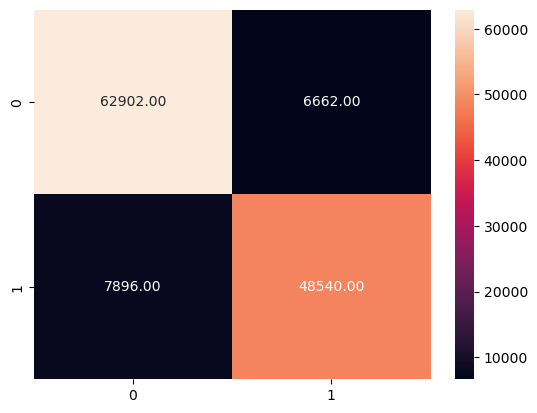

In [29]:
sns.heatmap(data=cm, annot=True, fmt='.2f')

## for compitition submission , we load their test data 

In [31]:
test = pd.read_csv('heartdtest.csv')
test.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


In [32]:
test2 = test.drop(columns=['id'])
test2.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,43,1,1,138,267,0,0,163,0,1.8,2,0,7


In [33]:
test2[num_cols] = sc.transform(test2[num_cols])

In [34]:
test2.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,0.467821,0.631521,-0.368138,-0.699744,1.278059,-0.294928,1.019633,-0.410243,1.629607,0.089145,0.997778,3.192507,-0.830314
1,0.104564,-1.583479,-1.542785,-0.699744,-1.068766,-0.294928,-0.982791,1.002543,-0.613645,-0.754717,-0.836433,-0.564872,-0.830314
2,-0.016521,0.631521,0.806509,-0.699744,0.683926,-0.294928,-0.982791,-0.148616,1.629607,-0.754717,0.997778,3.192507,1.221070
3,-1.227378,-1.583479,-0.368138,-1.234046,-2.019378,-0.294928,-0.982791,0.793241,-0.613645,0.194628,-0.836433,-0.564872,-0.830314
4,-1.348464,0.631521,-2.717432,0.502437,0.654219,-0.294928,-0.982791,0.531614,-0.613645,1.143973,0.997778,-0.564872,1.221070


In [35]:
y_pred2 = model.predict(test2)
y_pred2

array([1, 0, 1, ..., 0, 0, 0])

In [36]:
submission = pd.DataFrame({
    "id": test["id"],
    "Heart Disease": y_pred2
})
submission.head()


,id,Heart Disease
0,630000,1
1,630001,0
2,630002,1
3,630003,0
4,630004,0


In [37]:
submission.to_csv("submission.csv", index=False)


In [38]:
submission.shape

(270000, 2)